# __Box Filter (Motion Blur)__

After completing this reading material, you will be able to:

* Implement box filter and Motion blur
* Create vertical and horizontal kernel of motion blur

__Linear Filter__

You have already learned about Linear filters in the `Application of filters` Chapter. Now it is time to discuss a different class of linear filters. Linear filters of two class:
1. Smoothing filters

2. Difference filters

The two most popular two types of smoothing filters are:
* Box filter and
* Gaussian filter

You have already learned the Gaussian filter in `Gaussian Smoothing and Median filtering.` In this section, we will focus on the box filter only.

<!-- ![image](https://drive.google.com/uc?export=view&id=1tRhUbUvqAmRKy0XKsVZ-vH_9GVM0kbHi) -->

![image](https://i.postimg.cc/brYwwj7n/image.png)

# __Box filter__

Box filter is the simplest of all smoothing filters, whose 3D shape if plotted looks like a box. The Box filter is also known as an average filter, homogeneous filter, and mean-filter.
Therefore In a Box filter, you take the mean of all the pixels in the kernel/window  and replace the central element with calculated mean.




<center>

<!-- ![image](https://drive.google.com/uc?export=view&id=1LFjwcqWyKBJIWg0cZ0GfnC9m3J8KGZgM) -->

![image](https://i.postimg.cc/65yBjztB/image.png)
<figcaption>Figure 1: 3D shape of a Box filter </figcaption>
</center>

The box filter is not an optimal smoothing filter due to its bad performance in frequency space caused by the sharp cutoff around its sides. Smoothing corresponds to low-pass filtering, effectively reduce all signal components above a given cutoff frequency.

<center>

<!-- ![image](https://drive.google.com/uc?export=view&id=1A_LUcdQZl5upP8bozk26edmpotrucRYD) -->

![image](https://i.postimg.cc/mkJFFJZr/image.png)

<figcaption>Figure 2: 5 x 5 Normalized Box filter </figcaption>
</center>


Normalizing the kernel in this way prevents introducing a bias during filtering.

What will be the structure of 3*3 normalized Box filter?

In [ ]:
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=1N6hGsjL0zOgTvB3SCnlscKYL8cqwWae6' -O gaussian.PNG

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# read an image
img = cv2.imread('gaussian.PNG')

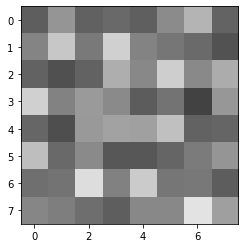

In [ ]:
test = img[0:8, 0:8]
plt.imshow(test)

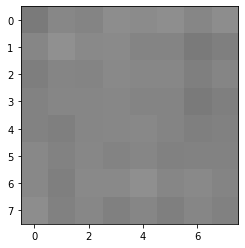

In [ ]:
kernelsize = (5,5)
# opencv has implementation for kernel based box blurring
test_boxfilter = cv2.blur(test,kernelsize)
plt.imshow(test_boxfilter)

In [ ]:
test_boxfilter[0]

array([[122, 122, 122],
       [135, 135, 135],
       [132, 132, 132],
       [141, 141, 141],
       [139, 139, 139],
       [142, 142, 142],
       [136, 136, 136],
       [136, 136, 136],
       [134, 134, 134],
       [131, 131, 131]], dtype=uint8)

_OpenCV provides the cv2.blur() or cv2.boxFilter() to perform box filter operation. Click [Here](https://docs.opencv.org/trunk/da/dc5/group__gapi__filters.html#gaa37a58b30753913cbcc7f5425726dbd5) for more details._

In [ ]:
kernelsize = (5,5)
# opencv has implementation for kernel based box blurring
img_boxfilter = cv2.blur(img,kernelsize)

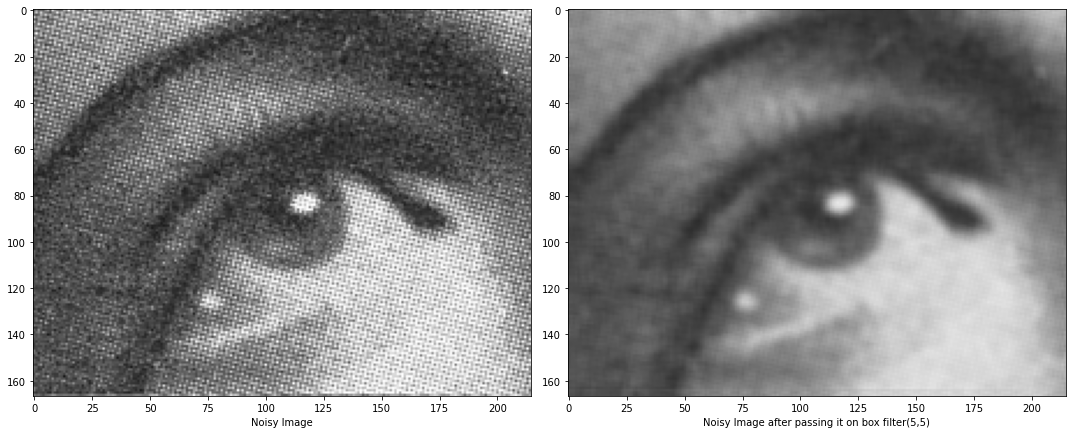

In [ ]:
f, axes = plt.subplots(1, 2, figsize=(15,10))
axes[0].imshow(img,cmap='gray')
axes[1].imshow(img_boxfilter,cmap='gray')
plt.setp(axes[0], xlabel='Noisy Image')
plt.setp(axes[1], xlabel='Noisy Image after passing it on box filter(5,5)')
f.tight_layout()
plt.savefig('boxfiler.png')
plt.show()

# __Motion Blur__

As name states, motion blur introduces a motion effect on the Image. Motion blur occurs when there is motion between the camera sensor and the object to be taken. If the movement is longer than the exposure time that is limited by
shutter speed then object moving with respect to the sensor appears blurred in an Image.

Motion blur always occurs in some direction. To introduce a motion blur, you need to define a kernel. Since it occurs in some direction, let’s discuss the vertical and horizontal motion. It’s like a directional low pass filter.A motion blur kernel takes mean of  the pixel values in defined direction.

This is an example of a $3*3$ horizontal motion-blurring kernel:

$$
K =
\begin{bmatrix}
0 & 0 & 0\\
1 & 1 & 1\\
0 & 0 & 0
\end{bmatrix}
$$

This is an example of a $3*3$ vertical motion-blurring kernel:

$$
K =
\begin{bmatrix}
0 & 1 & 0\\
0 & 1 & 0\\
0 & 1 & 0
\end{bmatrix}
$$

This kernel $K$ will blur the image in a horizontal direction. You can use vertical direction too. The amount of blur in image depends on the size of kernel. Use larger kernel for more blurry Image.

__Example:__

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Read the Image.

In [ ]:
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=19LT2PxpQqDx2U81McJESrSnoYZkS_kBu' -O horizontal.png

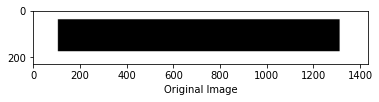

In [ ]:
horizontal_line = cv2.imread('/content/horizontal.png')
plt.imshow(horizontal_line)
plt.xlabel("Original Image")
plt.savefig("horizontal_line.png",dpi=600)

Define kernel size. If you use large kernel you wll see more motion.

In [ ]:
size = 45

__Create kernel:__

Fill the middle row with ones.

- For vertical fill in a column.
- For hoizontal fill in a row.


In [ ]:
kernel_motion_blur_h = np.zeros((size, size))
kernel_motion_blur_h[int((size-1)/2), :] = np.ones(size)
kernel_motion_blur_h = kernel_motion_blur_h / size

Display the kernel.

In [ ]:
kernel_motion_blur_h

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

You can transpose horizontal kernel to create vertical kernel.

In [ ]:
kernel_motion_blur_v = kernel_motion_blur_h.T

Define a function to plot three Images.

In [ ]:
# @title Plot three Images
def plot_three_images(original, vertical_blur, horizontal_blur):
    """
    Plots three Image at one time(subplots)

    Parameters
    ----------
    original: Original Image or numpy.ndarray
        Image to be blurred
    vertical_blur: Vertical Blurred Image or numpy.ndarray
        Image Blurred vertically
    horizontal_blur: Horizontally Blurred Image or numpy.ndarray
        Image Image Blurred horizontally
    """
    f, axes = plt.subplots(1, 3, figsize=(15,10))
    axes[0].imshow(original,cmap='gray')
    axes[1].imshow(vertical_blur,cmap='gray')
    axes[2].imshow(horizontal_blur,cmap='gray')
    plt.setp(axes[0], xlabel='Initially')
    plt.setp(axes[1], xlabel='Vertical Motion Blur')
    plt.setp(axes[2], xlabel='Horizontal Motion Blur')
    f.tight_layout()
    plt.savefig('vert hori.png',dpi=400)
    plt.show()

Apply both horizontal and vertical kernel of motion blur on horizontal line image. To apply kernel on the image filter2D() function is used. Let's apply the kernel and display the results on images.

In [ ]:
def apply_kernel(image,kernel):
    return cv2.filter2D(image, -1, kernel)

__Apply kernel on the Image with horizontal line__

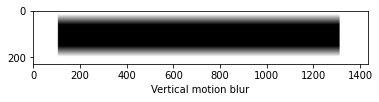

In [ ]:
v_blur_h_image = apply_kernel(horizontal_line,\
                              kernel_motion_blur_v)
plt.imshow(v_blur_h_image)
plt.xlabel('Vertical motion blur')
# plt.savefig('v_blur_h_image.png', dpi = 600)

You can see a mild black film on the upper and the lower slide of the image. It is due to vertical blur.

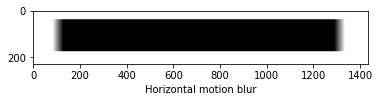

In [ ]:
h_blur_h_image = apply_kernel(horizontal_line,\
                              kernel_motion_blur_h)
plt.imshow(h_blur_h_image)
plt.xlabel('Horizontal motion blur')
# plt.savefig('h_blur_h_image.png', dpi = 600)

You can see a mild black film on the left side and the right slide of the image. It is due to horizontal blur.

Plot all the results.

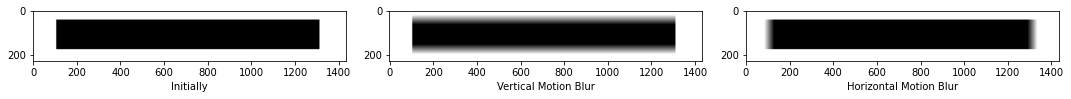

In [ ]:
plot_three_images(horizontal_line, v_blur_h_image, h_blur_h_image)

The picture above shows motion blur effect in  flame fire Image.

## Applications of motion blur

* Motion blur is used in sports photography to show motion to convey the sense of speed.

* It is used to create synthetic animation or scenes in movies.

# Disadvantages of Motion blur

* Using blur in online sports game is somehow controversial.

* Sometimes motion blur on the Image taken may cause of problem like hiding object of interest and hence you may need to do extra preprocessing.

* Motion blur may not exactly depict the exact position of an object.

# Key TakeAways

- Box filter is the simplest of all smoothing filters, whose 3D shape if plotted looks like a box.
-  Smoothing corresponds to low-pass filtering, effectively reduce all signal components above a given cutoff frequency.

- OpenCV provides the cv2.blur() or cv2.boxFilter() to perform box filter operation.

- Motion blur occurs due to motion between the camera image sensor and the object to be picked up when taking a picture.

- A motion blur kernel takes mean of the pixel values in a particular direction. The direction may be horizontal or vertical It’s like a directional low pass filter. This is an example of 3*3 horizontal motion-blurring kernel:

$$
K =
\begin{bmatrix}
0 & 0 & 0\\
1 & 1 & 1\\
0 & 0 & 0
\end{bmatrix}
$$